In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from enum import Enum
import os
from sklearn.ensemble import GradientBoostingClassifier
import time
import torch
from typing import List, Dict, Any

In [12]:
from temain import TemainProcess
import importlib
import v2_utils
import generators
import autoencoders
importlib.reload(v2_utils)
# importlib.reload(generators)
# importlib.reload(autoencoders)
from v2_utils import CSVDataLoader, ExperimentRunner, plot_with_anomalies, AdvancedDetectionEvaluator, BaseAnomalyDetector, ExperimentRunner
from autoencoders import RecurrentAutoencoder
from generators import ParallelDataGenerator, SingleProcessGenerator, N_DV

In [13]:


def run_experiments_by_anomaly(
        anomaly_numbers: List[int],
        data_dir_template: str = "./gen_data/gen_data_{}",
        model_params_list=None,
        file_fraction=0.01,
        anomaly_ratio=0.11,
        max_samples=None,
        result_title="",
        results_path="./results/my",
        window=30,
    ):
    normal_dir = data_dir_template.format(0)
    all_best_models = []
    all_best_per_detector = []
    
    for i in anomaly_numbers:
        print(f"\n{'='*50}")
        print(f"Запуск экспериментов для аномалии {i}")
        print(f"{'='*50}")
        start_time = time.time()
        
        data_dir = data_dir_template.format(i)
        autoencoder = RecurrentAutoencoder(
                    input_dim=53,
                    window_size=30,
                    hidden_dim=64,
                    latent_dim=32,
                    num_layers=1
                )
        model_saved_path = f"./models/new_autoencoder_w15.pth"
        autoencoder.load_state_dict(torch.load(model_saved_path))
        autoencoder.eval()
        
        data_gen = CSVDataLoader(data_dir, 
                                 file_fraction=file_fraction,
                                 normal_dir=normal_dir, 
                                 max_samples=max_samples,
                                 anomaly_ratio=anomaly_ratio,
                                 shuffle=True,
                                 normalize=True)
        
        runner = ExperimentRunner(data_gen, evaluator=AdvancedDetectionEvaluator)
        
        runner.register_detector(
            'IsolationForest', 
            IsolationForest,
            {'random_state': 42, 'contamination': 0.1}
        )

        runner.register_detector(
            'LocalOutlierFactor', 
            LocalOutlierFactor,
            {'contamination': 0.1, "novelty": True}
        )

        runner.register_detector(
            'OneClassSVM', 
            OneClassSVM,
            {'kernel': 'linear', 'nu': 0.1} # {'kernel': 'rbf', 'gamma': 'auto', 'nu': 0.1}
        )
        # runner.register_detector(
        #     'GradientBoosting', 
        #     GradientBoostingClassifier,
        #     {'random_state': 42}
        # )
        
        results = runner.run_comprehensive_experiments(
            model_params_list=model_params_list,
            test_delays=None,
            autoencoder=autoencoder,
            window=window,
        )
        
        filename = f"{results_path}/experiments_results_{i}.csv"
        # results.to_csv(filename, index=False)
        # print(f"Результаты сохранены в {filename}")
        
        best_pr = runner.get_best_models('pr_auc', top_k=1)
        best_pr['anomaly_number'] = i
        best_pr['best_by_metric'] = 'pr_auc'
        all_best_models.append(best_pr)
        
        best_roc = runner.get_best_models('roc_auc', top_k=1)
        best_roc['anomaly_number'] = i
        best_roc['best_by_metric'] = 'roc_auc'
        all_best_models.append(best_roc)
        # f1 ?
        
        best_per_detector = runner.get_best_per_detector('pr_auc')
        if not best_per_detector.empty:
            best_per_detector['anomaly_number'] = i
            all_best_per_detector.append(best_per_detector)

        best_pr.iloc[0]["survival_km"].plot_survival_function()
        plt.title('Функции выживаемости времени обнаружения аномалий')
        plt.ylabel('Вероятность необнаружения аномалии')
        plt.xlabel('Время (шаги)')
        # plt.ylim(0, 1)
        plt.grid(True)
        plt.show()
        
        print(f"Аномалия {i}:")
        print(f"  - Лучший PR AUC: {best_pr['pr_auc'].iloc[0]:.4f} ({best_pr['detector'].iloc[0]})")
        print(f"  - Лучший ROC AUC: {best_roc['roc_auc'].iloc[0]:.4f} ({best_roc['detector'].iloc[0]})")
        # print(f"  - Лучший F1: {best_f1['f1_score'].iloc[0]:.4f} ({best_f1['detector'].iloc[0]})")
        cur = time.time()
        print(f"\n-------------------\nВремя выполнения: {cur - start_time:.4f} секунд\n")
    
    if all_best_models and all_best_per_detector:
        summary_df = pd.concat(all_best_models, ignore_index=True)
        numeric_cols = summary_df.select_dtypes(include=['number', 'bool', 'int64', 'float64', 'string']).columns
        summary_df = summary_df[numeric_cols]
        summary_filename = f"{results_path}/best_models_summary{'_' + result_title if result_title else ''}.csv"
        summary_df.to_csv(summary_filename, index=False)
        print(f"\nСводная таблица сохранена в {summary_filename}")
        
        per_detector_df = pd.concat(all_best_per_detector, ignore_index=True)
        pivot_df = per_detector_df.pivot_table(
            index='anomaly_number', 
            columns='detector', 
            values='pr_auc',
            aggfunc='first'
        )
        pivot_filename = f"{results_path}/pr_auc_pivot{'_' + result_title if result_title else ''}.csv"
        pivot_df.to_csv(pivot_filename)
        print(f"Сводная таблица PR AUC по детекторам сохранена в {pivot_filename}")
        return summary_df, pivot_df

    
    return None, None




Запуск экспериментов для аномалии 1
   Итого: X.shape=(75744, 15, 53), y.shape=(75744,)
   Доля аномалий: 0.0475
Применяем автоэнкодер к данным. Исходная форма: (75744, 15, 53)
После автоэнкодера: (75744, 32)
X_train.shape=(53020, 32), y_train.shape=(53020,), X_test.shape=(22724, 32), y_test.shape=(22724,), y_train.mean()=0.047359486986043, y_test.mean()=0.04792290089772927


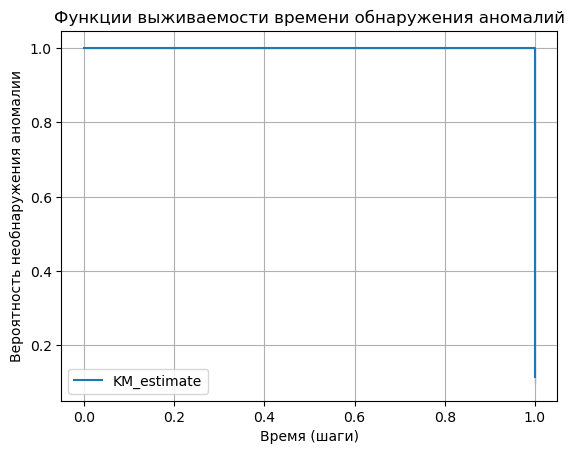

Аномалия 1:
  - Лучший PR AUC: 0.9565 (IsolationForest)
  - Лучший ROC AUC: 0.9892 (IsolationForest)

-------------------
Время выполнения: 241.6577 секунд


Запуск экспериментов для аномалии 2
   Итого: X.shape=(75744, 15, 53), y.shape=(75744,)
   Доля аномалий: 0.0475
Применяем автоэнкодер к данным. Исходная форма: (75744, 15, 53)
После автоэнкодера: (75744, 32)
X_train.shape=(53020, 32), y_train.shape=(53020,), X_test.shape=(22724, 32), y_test.shape=(22724,), y_train.mean()=0.047359486986043, y_test.mean()=0.04792290089772927


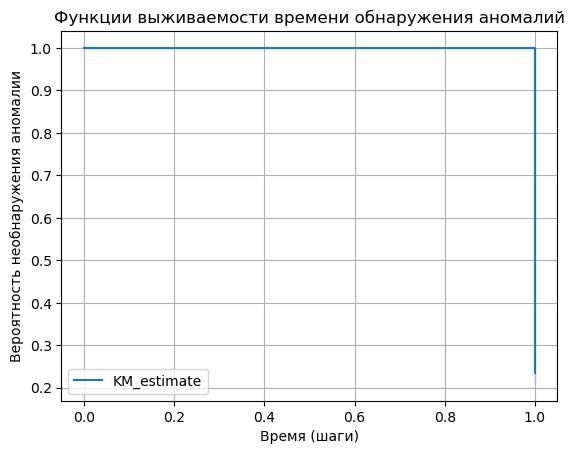

Аномалия 2:
  - Лучший PR AUC: 0.8434 (IsolationForest)
  - Лучший ROC AUC: 0.9475 (IsolationForest)

-------------------
Время выполнения: 260.3082 секунд


Запуск экспериментов для аномалии 3
   Итого: X.shape=(75744, 15, 53), y.shape=(75744,)
   Доля аномалий: 0.0475
Применяем автоэнкодер к данным. Исходная форма: (75744, 15, 53)
После автоэнкодера: (75744, 32)
X_train.shape=(53020, 32), y_train.shape=(53020,), X_test.shape=(22724, 32), y_test.shape=(22724,), y_train.mean()=0.047359486986043, y_test.mean()=0.04792290089772927


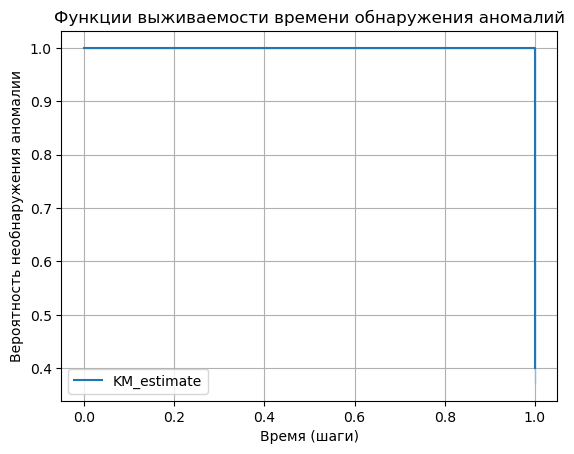

Аномалия 3:
  - Лучший PR AUC: 0.0560 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.5681 (LocalOutlierFactor)

-------------------
Время выполнения: 265.1679 секунд


Запуск экспериментов для аномалии 4
   Итого: X.shape=(75744, 15, 53), y.shape=(75744,)
   Доля аномалий: 0.0475
Применяем автоэнкодер к данным. Исходная форма: (75744, 15, 53)
После автоэнкодера: (75744, 32)
X_train.shape=(53020, 32), y_train.shape=(53020,), X_test.shape=(22724, 32), y_test.shape=(22724,), y_train.mean()=0.047359486986043, y_test.mean()=0.04792290089772927


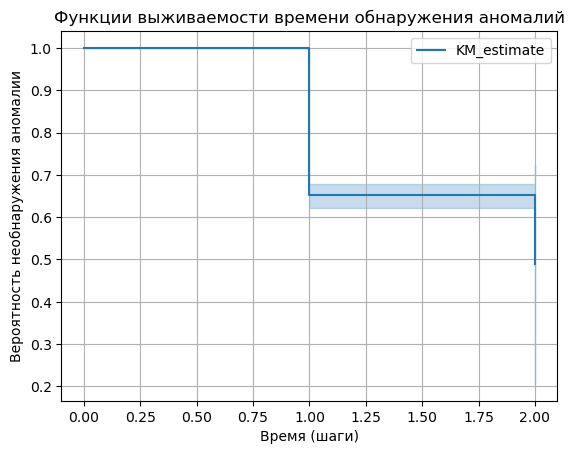

Аномалия 4:
  - Лучший PR AUC: 0.0812 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.6440 (LocalOutlierFactor)

-------------------
Время выполнения: 270.4045 секунд


Запуск экспериментов для аномалии 5
   Итого: X.shape=(75744, 15, 53), y.shape=(75744,)
   Доля аномалий: 0.0475
Применяем автоэнкодер к данным. Исходная форма: (75744, 15, 53)
После автоэнкодера: (75744, 32)
X_train.shape=(53020, 32), y_train.shape=(53020,), X_test.shape=(22724, 32), y_test.shape=(22724,), y_train.mean()=0.047359486986043, y_test.mean()=0.04792290089772927


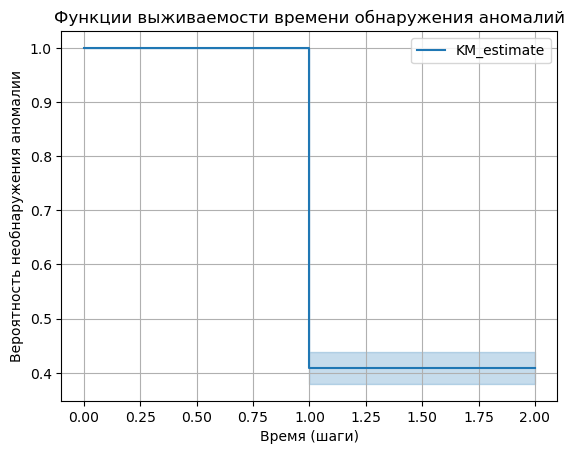

Аномалия 5:
  - Лучший PR AUC: 0.7127 (IsolationForest)
  - Лучший ROC AUC: 0.8949 (IsolationForest)

-------------------
Время выполнения: 251.8705 секунд


Запуск экспериментов для аномалии 6
   Итого: X.shape=(75744, 15, 53), y.shape=(75744,)
   Доля аномалий: 0.0475
Применяем автоэнкодер к данным. Исходная форма: (75744, 15, 53)
После автоэнкодера: (75744, 32)
X_train.shape=(53020, 32), y_train.shape=(53020,), X_test.shape=(22724, 32), y_test.shape=(22724,), y_train.mean()=0.047359486986043, y_test.mean()=0.04792290089772927


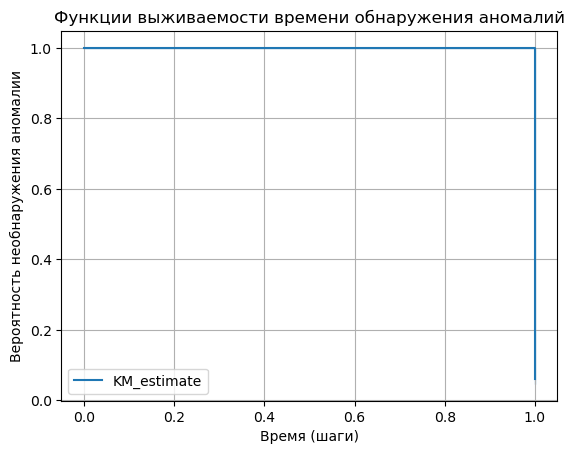

Аномалия 6:
  - Лучший PR AUC: 0.9698 (IsolationForest)
  - Лучший ROC AUC: 0.9921 (IsolationForest)

-------------------
Время выполнения: 254.2912 секунд


Запуск экспериментов для аномалии 7
   Итого: X.shape=(75744, 15, 53), y.shape=(75744,)
   Доля аномалий: 0.0475
Применяем автоэнкодер к данным. Исходная форма: (75744, 15, 53)
После автоэнкодера: (75744, 32)
X_train.shape=(53020, 32), y_train.shape=(53020,), X_test.shape=(22724, 32), y_test.shape=(22724,), y_train.mean()=0.047359486986043, y_test.mean()=0.04792290089772927


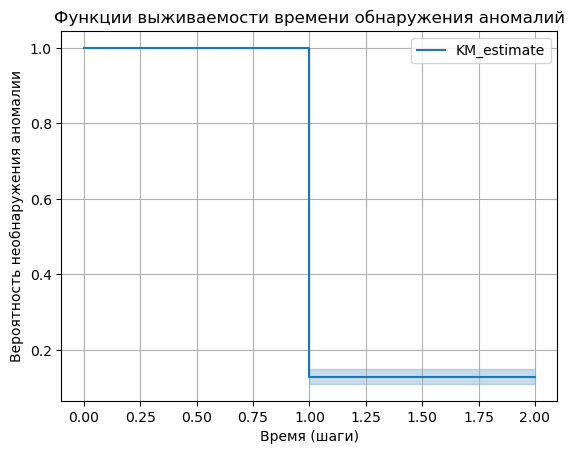

Аномалия 7:
  - Лучший PR AUC: 0.9521 (IsolationForest)
  - Лучший ROC AUC: 0.9933 (IsolationForest)

-------------------
Время выполнения: 249.7521 секунд


Запуск экспериментов для аномалии 8
   Итого: X.shape=(75744, 15, 53), y.shape=(75744,)
   Доля аномалий: 0.0475
Применяем автоэнкодер к данным. Исходная форма: (75744, 15, 53)
После автоэнкодера: (75744, 32)
X_train.shape=(53020, 32), y_train.shape=(53020,), X_test.shape=(22724, 32), y_test.shape=(22724,), y_train.mean()=0.047359486986043, y_test.mean()=0.04792290089772927


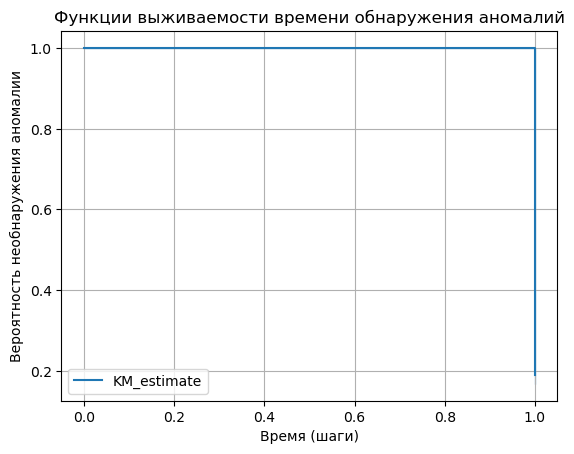

Аномалия 8:
  - Лучший PR AUC: 0.9062 (IsolationForest)
  - Лучший ROC AUC: 0.9600 (IsolationForest)

-------------------
Время выполнения: 248.2165 секунд


Запуск экспериментов для аномалии 9
   Итого: X.shape=(75744, 15, 53), y.shape=(75744,)
   Доля аномалий: 0.0475
Применяем автоэнкодер к данным. Исходная форма: (75744, 15, 53)
После автоэнкодера: (75744, 32)
X_train.shape=(53020, 32), y_train.shape=(53020,), X_test.shape=(22724, 32), y_test.shape=(22724,), y_train.mean()=0.047359486986043, y_test.mean()=0.04792290089772927


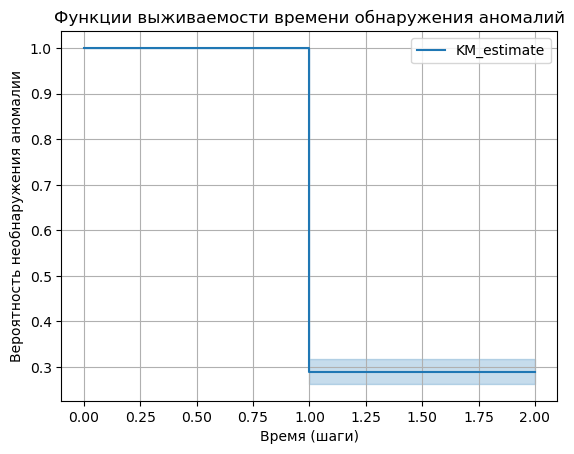

Аномалия 9:
  - Лучший PR AUC: 0.0541 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.5575 (LocalOutlierFactor)

-------------------
Время выполнения: 268.5352 секунд


Запуск экспериментов для аномалии 10
   Итого: X.shape=(75744, 15, 53), y.shape=(75744,)
   Доля аномалий: 0.0475
Применяем автоэнкодер к данным. Исходная форма: (75744, 15, 53)
После автоэнкодера: (75744, 32)
X_train.shape=(53020, 32), y_train.shape=(53020,), X_test.shape=(22724, 32), y_test.shape=(22724,), y_train.mean()=0.047359486986043, y_test.mean()=0.04792290089772927


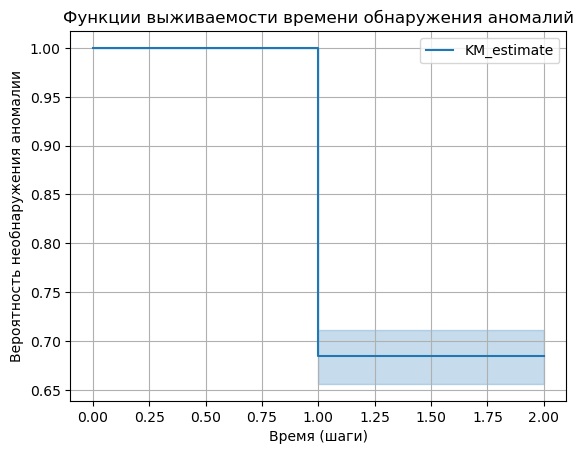

Аномалия 10:
  - Лучший PR AUC: 0.2991 (IsolationForest)
  - Лучший ROC AUC: 0.7982 (IsolationForest)

-------------------
Время выполнения: 271.8386 секунд


Запуск экспериментов для аномалии 11
   Итого: X.shape=(75744, 15, 53), y.shape=(75744,)
   Доля аномалий: 0.0475
Применяем автоэнкодер к данным. Исходная форма: (75744, 15, 53)
После автоэнкодера: (75744, 32)
X_train.shape=(53020, 32), y_train.shape=(53020,), X_test.shape=(22724, 32), y_test.shape=(22724,), y_train.mean()=0.047359486986043, y_test.mean()=0.04792290089772927


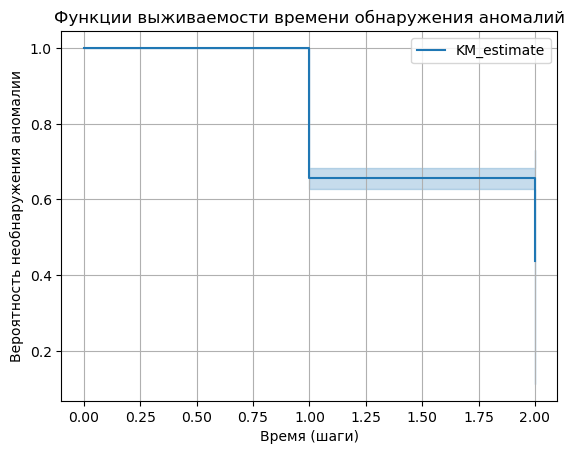

Аномалия 11:
  - Лучший PR AUC: 0.0630 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.5917 (LocalOutlierFactor)

-------------------
Время выполнения: 258.6745 секунд


Запуск экспериментов для аномалии 12
   Итого: X.shape=(75744, 15, 53), y.shape=(75744,)
   Доля аномалий: 0.0475
Применяем автоэнкодер к данным. Исходная форма: (75744, 15, 53)
После автоэнкодера: (75744, 32)
X_train.shape=(53020, 32), y_train.shape=(53020,), X_test.shape=(22724, 32), y_test.shape=(22724,), y_train.mean()=0.047359486986043, y_test.mean()=0.04792290089772927


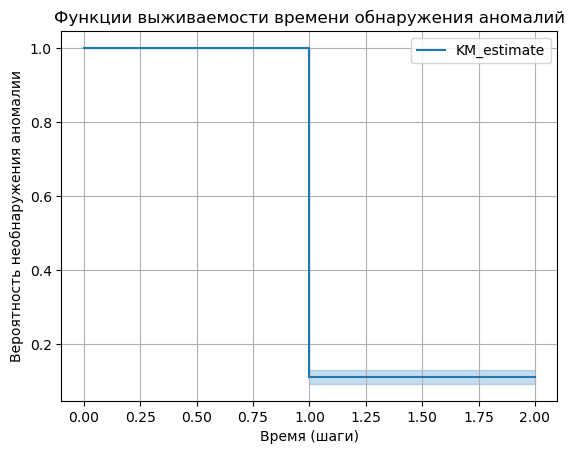

Аномалия 12:
  - Лучший PR AUC: 0.9436 (IsolationForest)
  - Лучший ROC AUC: 0.9769 (IsolationForest)

-------------------
Время выполнения: 251.2888 секунд


Запуск экспериментов для аномалии 13
   Итого: X.shape=(75744, 15, 53), y.shape=(75744,)
   Доля аномалий: 0.0475
Применяем автоэнкодер к данным. Исходная форма: (75744, 15, 53)
После автоэнкодера: (75744, 32)
X_train.shape=(53020, 32), y_train.shape=(53020,), X_test.shape=(22724, 32), y_test.shape=(22724,), y_train.mean()=0.047359486986043, y_test.mean()=0.04792290089772927


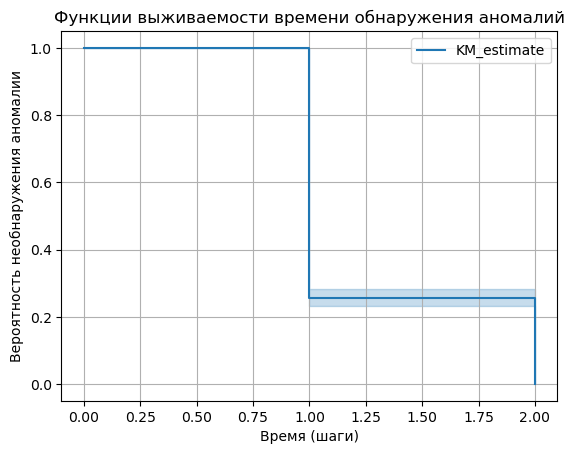

Аномалия 13:
  - Лучший PR AUC: 0.8247 (IsolationForest)
  - Лучший ROC AUC: 0.9328 (IsolationForest)

-------------------
Время выполнения: 252.0155 секунд


Запуск экспериментов для аномалии 14
   Итого: X.shape=(75744, 15, 53), y.shape=(75744,)
   Доля аномалий: 0.0475
Применяем автоэнкодер к данным. Исходная форма: (75744, 15, 53)
После автоэнкодера: (75744, 32)
X_train.shape=(53020, 32), y_train.shape=(53020,), X_test.shape=(22724, 32), y_test.shape=(22724,), y_train.mean()=0.047359486986043, y_test.mean()=0.04792290089772927


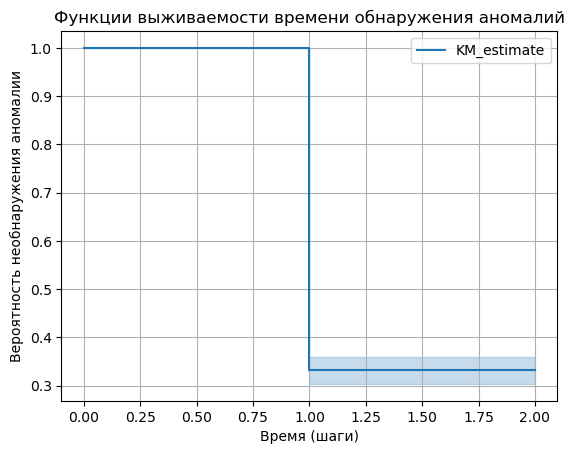

Аномалия 14:
  - Лучший PR AUC: 0.0525 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.5484 (LocalOutlierFactor)

-------------------
Время выполнения: 260.1748 секунд


Запуск экспериментов для аномалии 15
   Итого: X.shape=(75744, 15, 53), y.shape=(75744,)
   Доля аномалий: 0.0475
Применяем автоэнкодер к данным. Исходная форма: (75744, 15, 53)
После автоэнкодера: (75744, 32)
X_train.shape=(53020, 32), y_train.shape=(53020,), X_test.shape=(22724, 32), y_test.shape=(22724,), y_train.mean()=0.047359486986043, y_test.mean()=0.04792290089772927


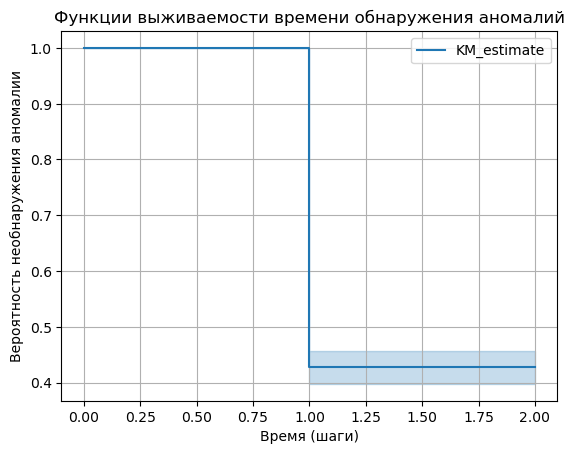

Аномалия 15:
  - Лучший PR AUC: 0.0581 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.5797 (LocalOutlierFactor)

-------------------
Время выполнения: 265.1717 секунд


Запуск экспериментов для аномалии 16
   Итого: X.shape=(75744, 15, 53), y.shape=(75744,)
   Доля аномалий: 0.0475
Применяем автоэнкодер к данным. Исходная форма: (75744, 15, 53)
После автоэнкодера: (75744, 32)
X_train.shape=(53020, 32), y_train.shape=(53020,), X_test.shape=(22724, 32), y_test.shape=(22724,), y_train.mean()=0.047359486986043, y_test.mean()=0.04792290089772927


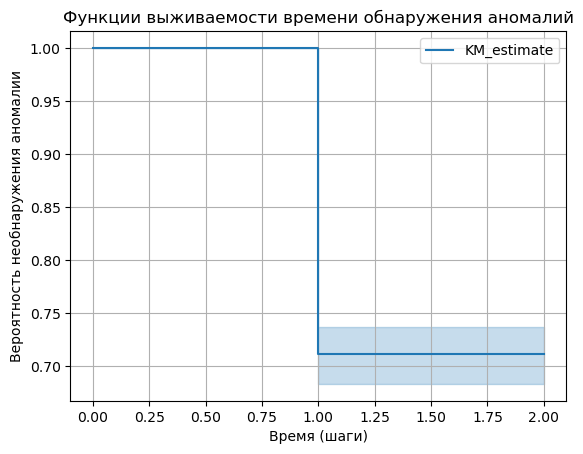

Аномалия 16:
  - Лучший PR AUC: 0.1463 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.6871 (LocalOutlierFactor)

-------------------
Время выполнения: 255.2846 секунд


Запуск экспериментов для аномалии 17
   Итого: X.shape=(75744, 15, 53), y.shape=(75744,)
   Доля аномалий: 0.0475
Применяем автоэнкодер к данным. Исходная форма: (75744, 15, 53)
После автоэнкодера: (75744, 32)
X_train.shape=(53020, 32), y_train.shape=(53020,), X_test.shape=(22724, 32), y_test.shape=(22724,), y_train.mean()=0.047359486986043, y_test.mean()=0.04792290089772927


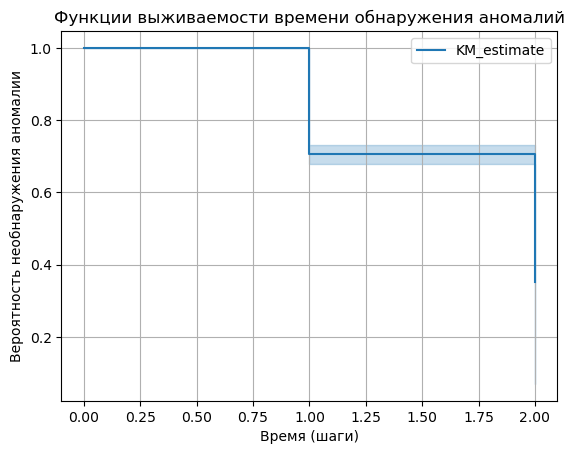

Аномалия 17:
  - Лучший PR AUC: 0.2774 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.7722 (LocalOutlierFactor)

-------------------
Время выполнения: 275.1109 секунд


Запуск экспериментов для аномалии 18
   Итого: X.shape=(75744, 15, 53), y.shape=(75744,)
   Доля аномалий: 0.0475
Применяем автоэнкодер к данным. Исходная форма: (75744, 15, 53)
После автоэнкодера: (75744, 32)
X_train.shape=(53020, 32), y_train.shape=(53020,), X_test.shape=(22724, 32), y_test.shape=(22724,), y_train.mean()=0.047359486986043, y_test.mean()=0.04792290089772927


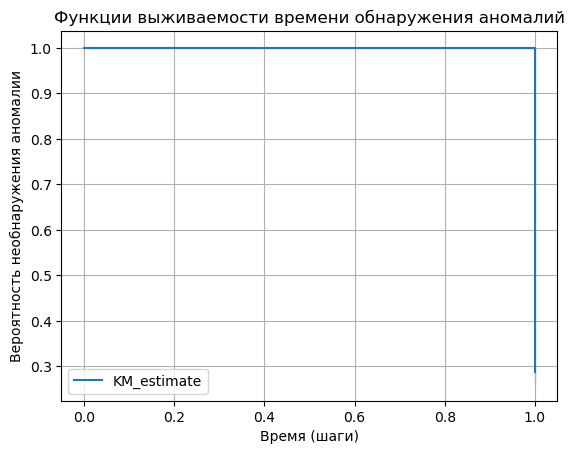

Аномалия 18:
  - Лучший PR AUC: 0.7798 (IsolationForest)
  - Лучший ROC AUC: 0.9024 (IsolationForest)

-------------------
Время выполнения: 261.4368 секунд


Запуск экспериментов для аномалии 19
   Итого: X.shape=(75744, 15, 53), y.shape=(75744,)
   Доля аномалий: 0.0475
Применяем автоэнкодер к данным. Исходная форма: (75744, 15, 53)
После автоэнкодера: (75744, 32)
X_train.shape=(53020, 32), y_train.shape=(53020,), X_test.shape=(22724, 32), y_test.shape=(22724,), y_train.mean()=0.047359486986043, y_test.mean()=0.04792290089772927


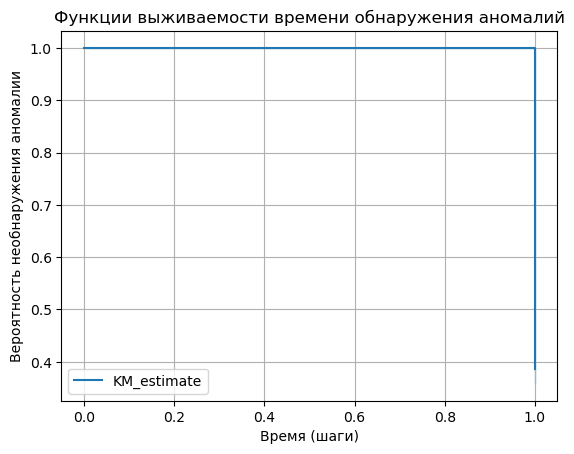

Аномалия 19:
  - Лучший PR AUC: 0.0570 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.5759 (LocalOutlierFactor)

-------------------
Время выполнения: 267.0592 секунд


Сводная таблица сохранена в results/cleared/best_models_summary_new_data_unsupervised_with_autoencoder.csv
Сводная таблица PR AUC по детекторам сохранена в results/cleared/pr_auc_pivot_new_data_unsupervised_with_autoencoder.csv


In [14]:
model_params_list = {
    'IsolationForest': [
        # {'n_estimators': 200, 'contamination': 0.1, "random_state": 42},
        {'n_estimators': 100, 'max_samples': 'auto', 'contamination': 0.1, 'random_state': 42},
        {'n_estimators': 200, 'max_samples': 0.8, 'contamination': 0.05, 'random_state': 42},
        {'n_estimators': 50, 'max_samples': 1.0, 'contamination': 0.15, 'random_state': 42},
        # {'n_estimators': 100, 'max_samples': 0.5, 'contamination': 'auto', 'random_state': 42}
    ],
    'LocalOutlierFactor': [
        # {'n_neighbors': 50, 'contamination': 0.1, 'novelty': True},
        {'n_neighbors': 20, 'contamination': 0.1, 'novelty': True},
        {'n_neighbors': 10, 'contamination': 0.05, 'novelty': True},
        {'n_neighbors': 50, 'contamination': 0.15, 'novelty': True},
        # {'n_neighbors': 20, 'contamination': 'auto', 'novelty': True}
    ],
    'OneClassSVM': [
        # {'kernel': 'rbf', 'nu': 0.1},
        # {'kernel': 'rbf', 'nu': 0.15},
        {'kernel': 'linear', 'nu': 0.15},
        {'kernel': 'linear', 'nu': 0.2},
        # {'kernel': 'poly', 'nu': 0.15},
    ],
    # 'GradientBoosting': [
    #     {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'random_state': 42},
    #     {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'random_state': 42},
    #     {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'random_state': 42},
    # ]
}

anomaly_numbers = list(range(1, 20))
# anomaly_numbers = [6, 7, 8]

summary, summary_detectors = run_experiments_by_anomaly(anomaly_numbers,
                                     data_dir_template="./gen_data_new/gen_data_{}",
                                     model_params_list=model_params_list,
                                     max_samples=100000,
                                     file_fraction=0.02,
                                     anomaly_ratio=0.07,
                                     window=15,
                                     result_title="new_data_unsupervised_with_autoencoder",
                                     results_path="results/cleared"
                                     )

In [15]:
summary

,roc_auc,pr_auc,optimal_thr,detection_latency,survival_mttd,n_estimators,contamination,random_state,size,anomaly_ratio,n_neighbors,nu,anomaly_number
0,0.989182,0.956490,0.565449,0.000000,2.287823,200.0,0.05,42.0,75744,0.047529,NaN,NaN,1
1,0.989182,0.956490,0.565449,0.000000,2.287823,200.0,0.05,42.0,75744,0.047529,NaN,NaN,1
2,0.947476,0.843435,0.748675,0.000000,4.667897,100.0,0.10,42.0,75744,0.047529,NaN,NaN,2
3,0.947476,0.843435,0.748675,0.000000,4.667897,100.0,0.10,42.0,75744,0.047529,NaN,NaN,2
4,0.568057,0.055965,0.232167,0.000000,7.988930,NaN,0.15,NaN,75744,0.047529,50.0,NaN,3
5,0.568057,0.055965,0.232167,0.000000,7.988930,NaN,0.15,NaN,75744,0.047529,50.0,NaN,3
6,0.644024,0.081190,0.435501,0.002639,9.932196,NaN,0.15,NaN,75744,0.047529,50.0,NaN,4
7,0.644024,0.081190,0.435501,0.002639,9.932196,NaN,0.15,NaN,75744,0.047529,50.0,NaN,4
8,0.890044,0.712682,0.721184,0.000000,8.173432,200.0,0.05,42.0,75744,0.047529,NaN,NaN,5
9,0.894923,0.711665,0.824977,0.001558,5.585178,50.0,0.15,42.0,75744,0.047529,NaN,NaN,5


In [16]:
summary_detectors

detector,IsolationForest,LocalOutlierFactor,OneClassSVM
anomaly_number,,,
1,0.956490,0.060273,0.175781
2,0.843435,0.080624,0.274410
3,0.051493,0.055965,0.042180
4,0.063043,0.081190,0.036643
5,0.712682,0.125627,0.046286
6,0.969818,0.097876,0.918182
7,0.952111,0.220720,0.103255
8,0.906156,0.371263,0.032324
9,0.048501,0.054082,0.046097
